# SeqOptPlot.parallel_coordinates — many-objective trade-offs\n\nFor more than two objectives, a parallel-coordinates plot shows each Pareto-front variant as a line across the (min-max normalized) objective axes, colored by non-dominated rank.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import aaanalysis as aa
aa.options["verbose"] = False

# Gamma-secretase (GSEC) substrate data + the bundled interpretable CPP feature set.
df_feat = aa.load_features(name="DOM_GSEC")           # 150 CPP features (with positions, feat_importance)
df_seq  = aa.load_dataset(name="DOM_GSEC", n=50)      # 100 TMD sequences, label 1 = GSEC substrate
labels  = df_seq["label"].to_list()

# A simple RandomForest substrate classifier on the CPP feature matrix.
sf = aa.SequenceFeature()
X = np.asarray(sf.feature_matrix(features=df_feat["feature"],
                                 df_parts=sf.get_df_parts(df_seq=df_seq),
                                 df_scales=aa.load_scales()), dtype=float)
model = RandomForestClassifier(n_estimators=100, random_state=0).fit(X, labels)

# Pick a NON-substrate as the wild-type and design a "super substrate": mutate its TMD to
# maximize the predicted substrate probability with as few mutations as possible.
wt = df_seq[df_seq["label"] == 0].iloc[[0]].reset_index(drop=True)
objectives = [("substrate", "max", "delta_pred"),     # raise P(GSEC substrate) (RF prediction shift)
              ("parsimony", "min", "n_mut")]          # with as few mutations as possible


In [2]:
objectives3 = [("substrate", "max", "delta_pred"),    # raise predicted substrate probability
               ("stability", "min", "delta_cpp"),     # keep the feature profile close to natural
               ("parsimony", "min", "n_mut")]         # few mutations
seqopt = aa.SeqOpt(mode="importance", model=model, target_class=1, random_state=42)
df_pareto = seqopt.run(df_seq=wt, df_feat=df_feat, objectives=objectives3,
                       pop_size=40, n_gen=20, n_mut_max=5, region="tmd")
aa.display_df(df_pareto, n_rows=10, show_shape=True)


DataFrame shape: (28, 9)


,entry,variant,n_mut,sequence_mut,substrate,stability,parsimony,rank,crowding
1,Q14802,,0,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,0.000000,0.000000,0.000000,0,inf
2,Q14802,G52L+I55T+S58R+A59R,4,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,36.000000,7.264650,4.000000,0,inf
3,Q14802,V39P+A50K+I55V+S58R+A59R,5,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,30.000000,5.449390,5.000000,0,inf
4,Q14802,S58Q+A59R,2,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,21.000000,3.693250,2.000000,0,0.140833
5,Q14802,S58R,1,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,14.000000,1.549330,1.000000,0,0.138603
6,Q14802,I55V+S58Q+A59R,3,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,25.000000,3.969830,3.000000,0,0.135056
7,Q14802,S58V,1,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,8.000000,0.616080,1.000000,0,0.120829
8,Q14802,A50K+S58Q,2,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,8.000000,0.472060,2.000000,0,0.109567
9,Q14802,G52L+S58R+A59R,3,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,34.000000,6.589060,3.000000,0,0.093956
10,Q14802,G52W+S58R+A59R,3,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,31.000000,6.094060,3.000000,0,0.087474


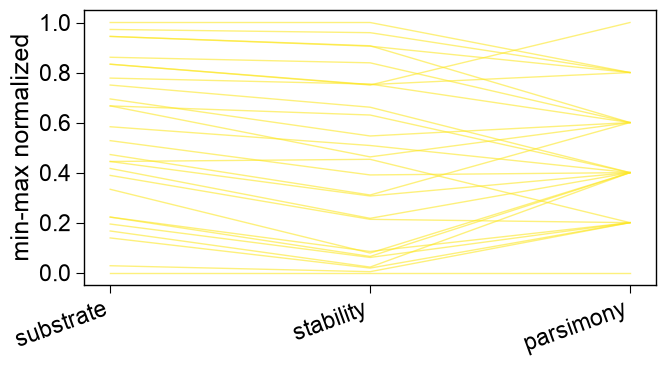

In [3]:
aa.plot_settings()
aa.SeqOptPlot().parallel_coordinates(
    df_pareto=df_pareto, objectives=["substrate", "stability", "parsimony"],
    front_only=True)
plt.tight_layout(); plt.show()